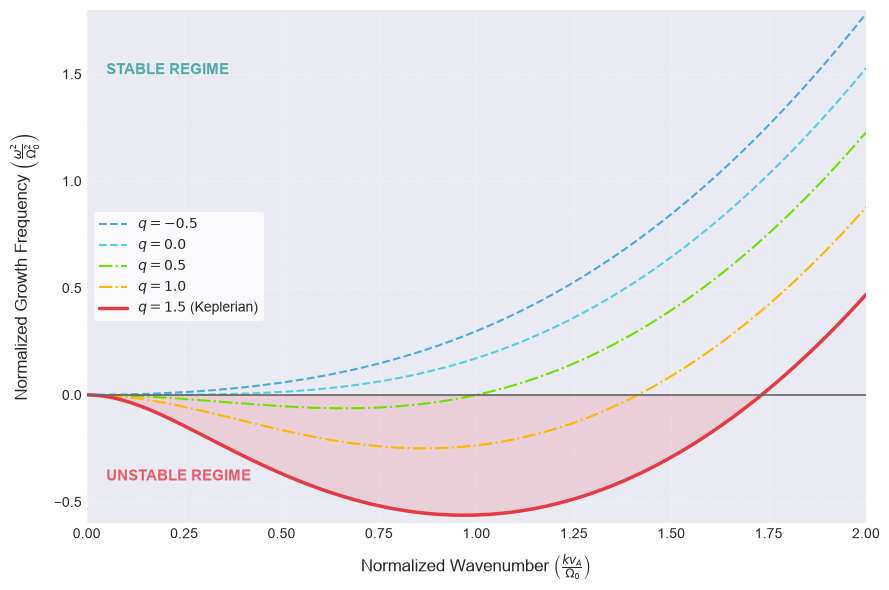

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 2.0, 500)

q_values = [-0.5, 0.0, 0.5, 1.0, 1.5]

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 6))


colors = {
    -0.5: '#4EA8DE',  # Light Blue
    0.0:  '#56CFE1',  # Cyan
    0.5:  '#70E000',  # Green
    1.0:  '#FFB703',  # Orange
    1.5:  '#E63946'   # Coral/Red (Keplerian)
}


for q in q_values:
   
    B = -(2 * x**2 + 2 * (2 - q))
    C = x**2 * (x**2 - 2 * q)
    

    y = (-B - np.sqrt(B**2 - 4 * C)) / 2
    
    if q == 1.5:

        ax.plot(x, y, color=colors[q], linewidth=2.5, linestyle='-', label=r'$q = 1.5$ (Keplerian)')
      
        ax.fill_between(x, y, 0, where=(y < 0), color=colors[q], alpha=0.15)
    else:

        ls = '--' if q <= 0 else '-.'
        ax.plot(x, y, color=colors[q], linewidth=1.5, linestyle=ls, label=r'$q = ' + f'{q}$')

ax.axhline(0, color='#666666', linestyle='-', linewidth=1.2)


ax.set_xlabel(r'Normalized Wavenumber $\left(\frac{k v_A}{\Omega_0}\right)$', fontsize=12, labelpad=10)
ax.set_ylabel(r'Normalized Growth Frequency $\left(\frac{\omega^2}{\Omega_0^2}\right)$', fontsize=12, labelpad=10)

ax.text(0.05, 1.5, 'STABLE REGIME', fontsize=11, fontweight='bold', color='#2A9D8F', alpha=0.8)
ax.text(0.05, -0.4, 'UNSTABLE REGIME', fontsize=11, fontweight='bold', color='#E63946', alpha=0.8)


ax.set_xlim(0.0, 2.0)
ax.set_ylim(-0.6, 1.8)
ax.grid(True, linestyle=':', alpha=0.6)


ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

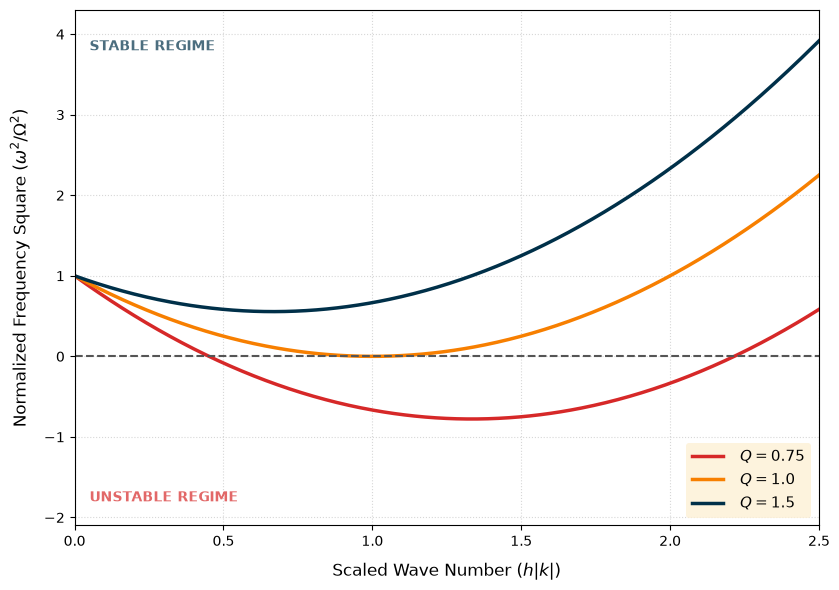

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 2.5, 500)

Q_values = [0.75, 1.0, 1.5]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8.5, 6))


colors = {
    0.75: '#D62828', 
    1.00: '#F77F00', 
    1.50: '#003049'  
}

for Q in Q_values:

    y = 1 - (2 * x) / Q + x**2
    

    ax.plot(x, y, color=colors[Q], linewidth=2.5, label=f' $Q = {Q}$')


ax.axhline(0, color='#555555', linestyle='--', linewidth=1.5)

ax.set_xlabel(r'Scaled Wave Number ($h|k|$)', fontsize=12, labelpad=10)
ax.set_ylabel(r'Normalized Frequency Square ($\omega^{2}/\Omega^{2}$)', fontsize=12, labelpad=10)


ax.text(0.05, 3.8, 'STABLE REGIME', fontsize=10, color='#003049', fontweight='bold', alpha=0.7)
ax.text(0.05, -1.8, 'UNSTABLE REGIME', fontsize=10, color='#D62828', fontweight='bold', alpha=0.7)


ax.set_xlim(0.0, 2.5)
ax.set_ylim(-2.1, 4.3)

ax.grid(True, linestyle=':', alpha=0.5)


ax.legend(loc='best', frameon=True, facecolor='#FDF0D5', edgecolor='none', fontsize=11)

plt.tight_layout()
plt.show()

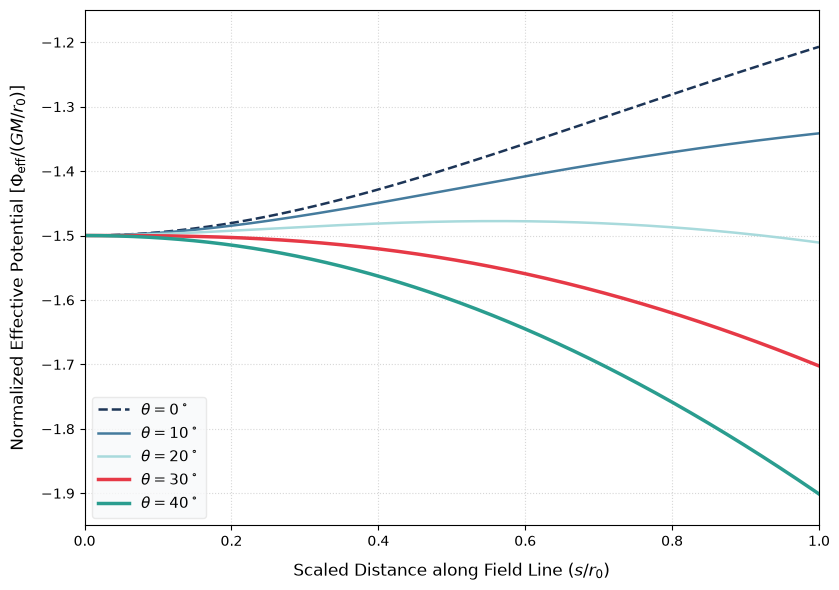

In [9]:
import numpy as np
import matplotlib.pyplot as plt


s_scaled = np.linspace(0.0, 1.0, 500)


GM = 1.0
r_0 = 1.0
Omega_0 = 1.0


angles_deg = [0, 10, 20, 30, 40]


plt.style.use('default')
fig, ax = plt.subplots(figsize=(8.5, 6))


colors = {
    0:  '#1D3557',  # Navy Blue
    10: '#457B9D',  # Steel Blue
    20: '#A8DADC',  # Light Cyan
    30: '#E63946',  # Crimson (The critical threshold)
    40: '#2A9D8F'   # Emerald Green
}


for angle in angles_deg:
    theta = np.radians(angle)
    

    grav_term = -GM / np.sqrt(s_scaled**2 + 2 * s_scaled * r_0 * np.sin(theta) + r_0**2)
    cent_term = -0.5 * (Omega_0**2) * (r_0 + s_scaled * np.sin(theta))**2
    

    phi_eff = grav_term + cent_term
    

    lw = 2.5 if angle in [30, 40] else 1.8
    ls = '-' if angle == 30 else '--' if angle == 0 else '-'
    
    ax.plot(s_scaled, phi_eff, color=colors[angle], linewidth=lw, linestyle=ls, label=f'$\\theta = {angle}^\\circ$')


ax.set_xlabel(r'Scaled Distance along Field Line ($s/r_0$)', fontsize=12, labelpad=10)
ax.set_ylabel(r'Normalized Effective Potential $\left[\Phi_{\mathrm{eff}} / (GM/r_0)\right]$', fontsize=12, labelpad=10)




ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.95, -1.15)


ax.grid(True, linestyle=':', alpha=0.5)

ax.legend(loc='lower left', frameon=True, facecolor='#F8F9FA', edgecolor='#E5E5E5', fontsize=11)

plt.tight_layout()
plt.show()